In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/box_office_revenue_1000_movies(1).csv")

print(df.head())

   Movie_ID     Genre  Release_Year  Runtime_Minutes  Budget_Million  \
0         1   Romance          2010               86           99.97   
1         2    Horror          2024               79           78.77   
2         3  Thriller          2017               78           58.76   
3         4    Sci-Fi          2021              137           46.03   
4         5   Romance          2020              128           63.07   

   Marketing_Million  Opening_Weekend_Million  Theater_Count  IMDb_Rating  \
0              48.67                    43.05           2708          7.4   
1              29.11                    49.05           2333          6.6   
2              13.97                    39.01           3382          8.1   
3               7.52                    24.20           2018          7.1   
4              14.88                    39.35           3289          9.0   

   Critic_Score  Audience_Score  Star_Power Franchise Sequel  \
0            88              82         

In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

In [5]:
top_movies = df.sort_values(
    by="Box_Office_Revenue_Million",
    ascending=False
).head(10)

print("\nTop 10 Movies by Box Office Revenue:")

print(
    top_movies[
        ["Movie_ID", "Genre", "Release_Year", "Box_Office_Revenue_Million"]
    ]
)


Top 10 Movies by Box Office Revenue:
     Movie_ID      Genre  Release_Year  Box_Office_Revenue_Million
14         15  Animation          2024                      1200.0
469       470  Adventure          2011                      1200.0
35         36     Sci-Fi          2023                      1200.0
391       392     Sci-Fi          2012                      1200.0
486       487     Action          2019                      1200.0
20         21     Sci-Fi          2018                      1200.0
44         45    Fantasy          2012                      1200.0
865       866  Animation          2015                      1200.0
214       215  Adventure          2014                      1200.0
246       247     Action          2012                      1200.0


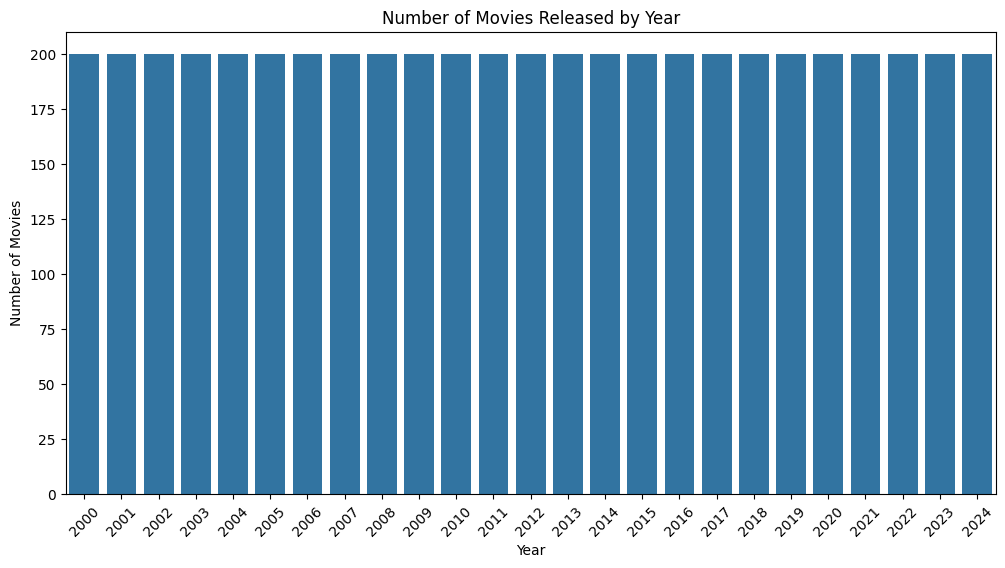

In [ ]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="Year"
)

plt.title("Number of Movies Released by Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()



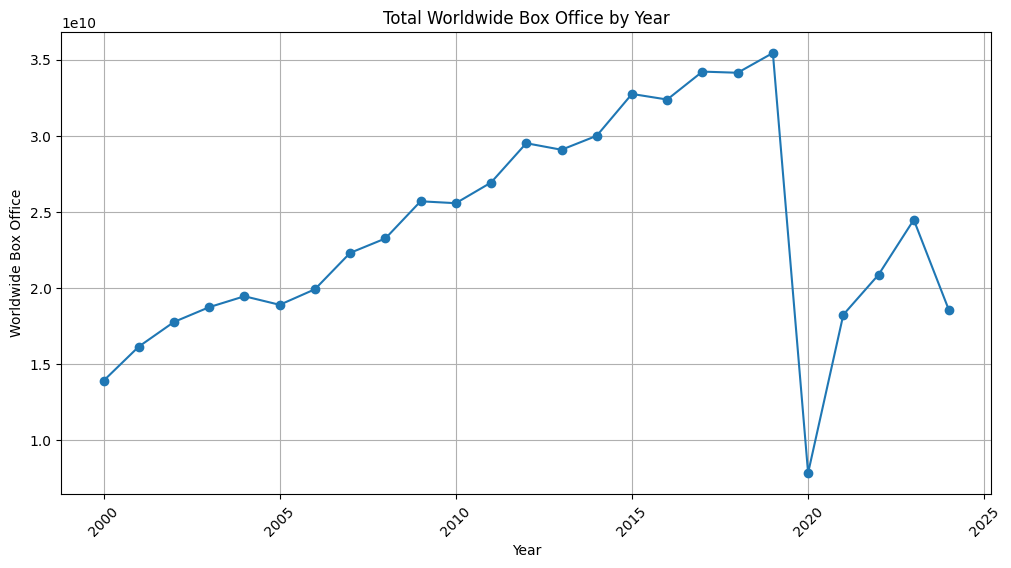

In [ ]:
yearly_boxoffice = df.groupby("Year")["$Worldwide"].sum()

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_boxoffice.index,
    yearly_boxoffice.values,
    marker="o"
)

plt.title("Total Worldwide Box Office by Year")
plt.xlabel("Year")
plt.ylabel("Worldwide Box Office")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


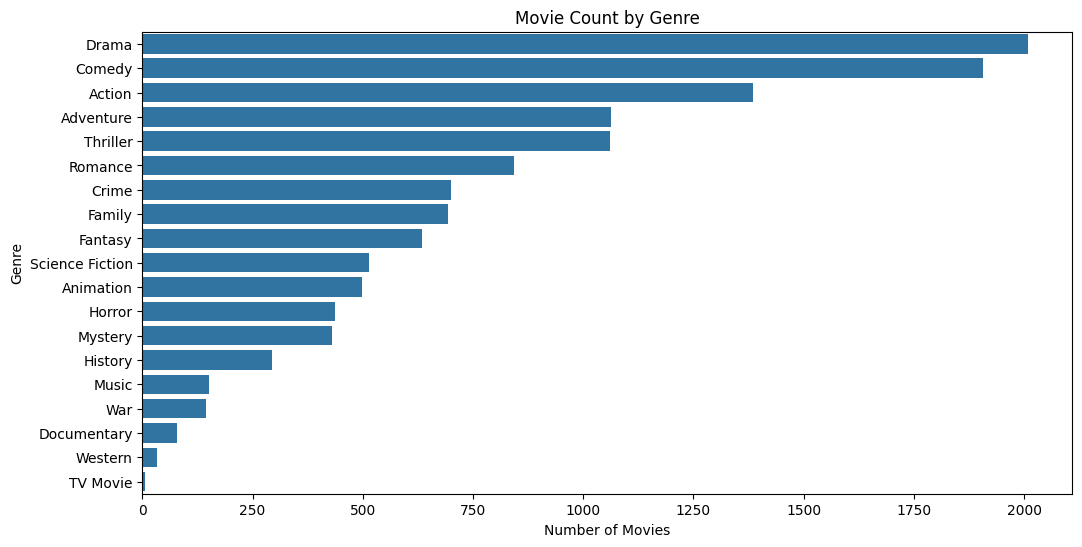

In [ ]:
# Split multiple genres
genre_df = df.assign(
    Genres=df["Genres"].str.split(", ")
).explode("Genres")

genre_counts = genre_df["Genres"].value_counts()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index
)

plt.title("Movie Count by Genre")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

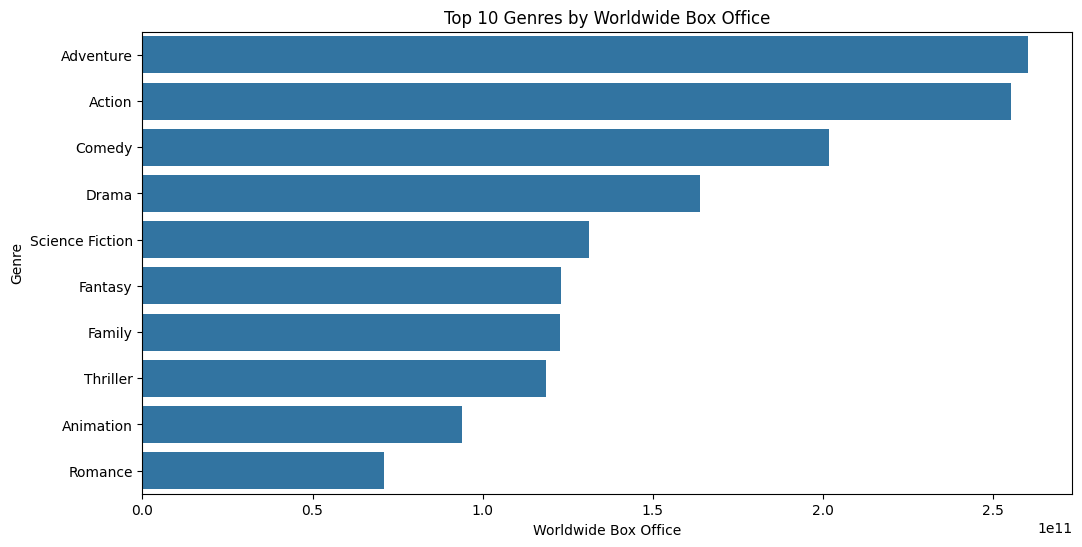

In [ ]:
genre_boxoffice = (
    genre_df.groupby("Genres")["$Worldwide"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_boxoffice.values,
    y=genre_boxoffice.index
)

plt.title("Top 10 Genres by Worldwide Box Office")
plt.xlabel("Worldwide Box Office")
plt.ylabel("Genre")
plt.show()


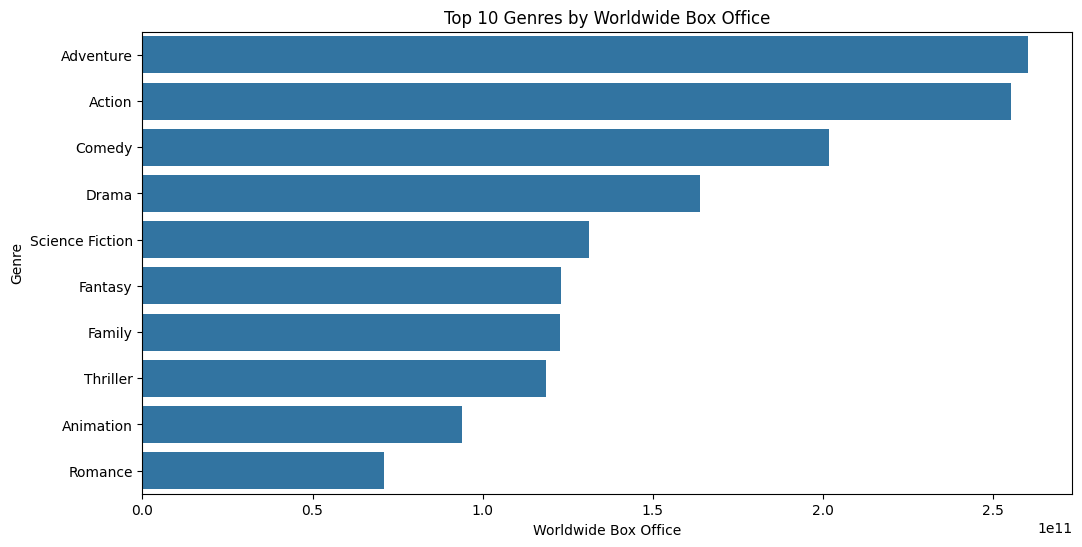

In [ ]:
genre_boxoffice = (
    genre_df.groupby("Genres")["$Worldwide"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=genre_boxoffice.values,
    y=genre_boxoffice.index
)

plt.title("Top 10 Genres by Worldwide Box Office")
plt.xlabel("Worldwide Box Office")
plt.ylabel("Genre")
plt.show()


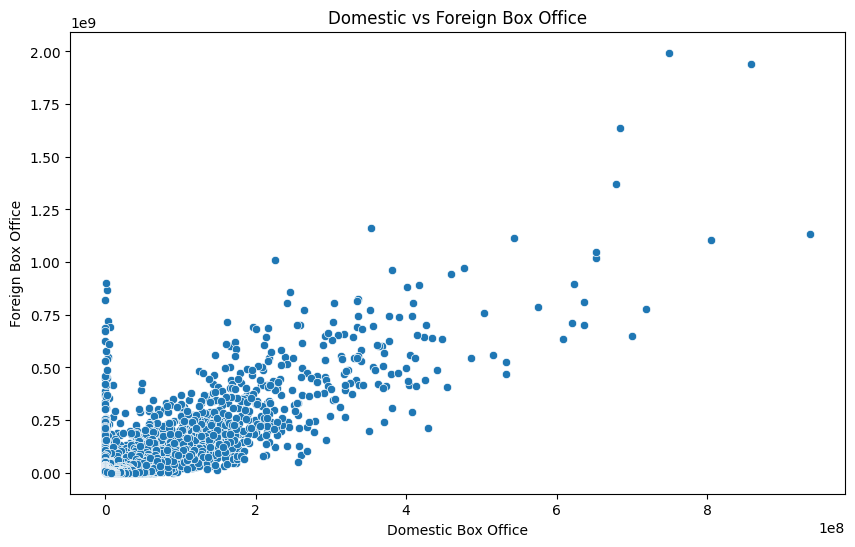

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="$Domestic",
    y="$Foreign"
)

plt.title("Domestic vs Foreign Box Office")
plt.xlabel("Domestic Box Office")
plt.ylabel("Foreign Box Office")
plt.show()

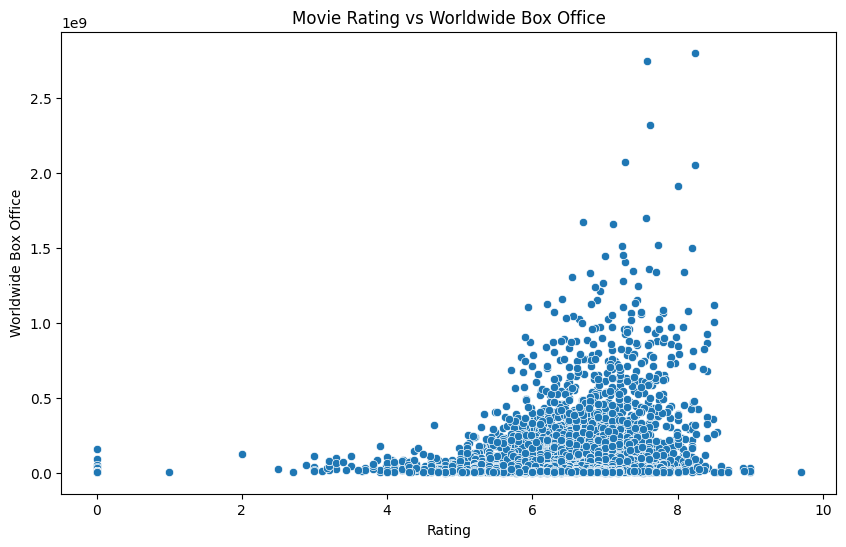

In [ ]:
df["Rating_Numeric"] = pd.to_numeric(
    df["Rating"].astype(str).str.extract(r"(\d+\.?\d*)")[0],
    errors="coerce"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rating_Numeric",
    y="$Worldwide"
)

plt.title("Movie Rating vs Worldwide Box Office")
plt.xlabel("Rating")
plt.ylabel("Worldwide Box Office")
plt.show()

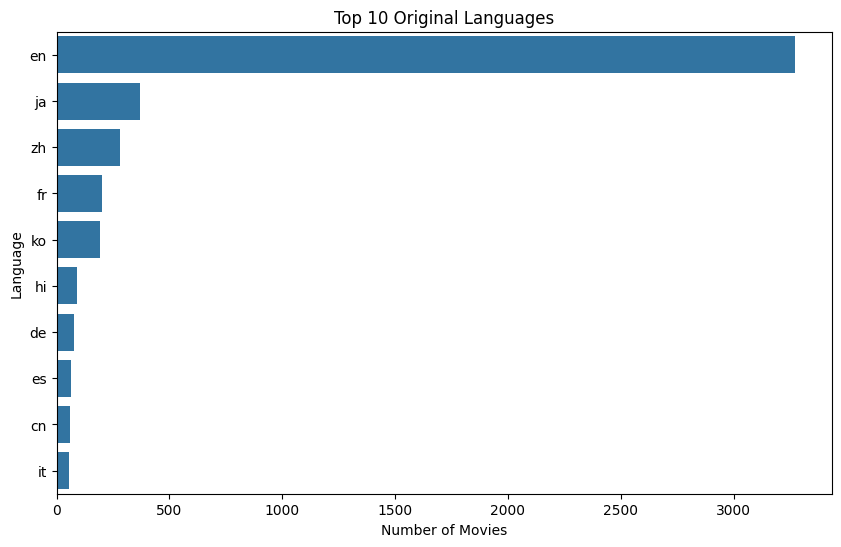

In [ ]:
language_counts = df["Original_Language"].value_counts().head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=language_counts.values,
    y=language_counts.index
)

plt.title("Top 10 Original Languages")
plt.xlabel("Number of Movies")
plt.ylabel("Language")
plt.show()


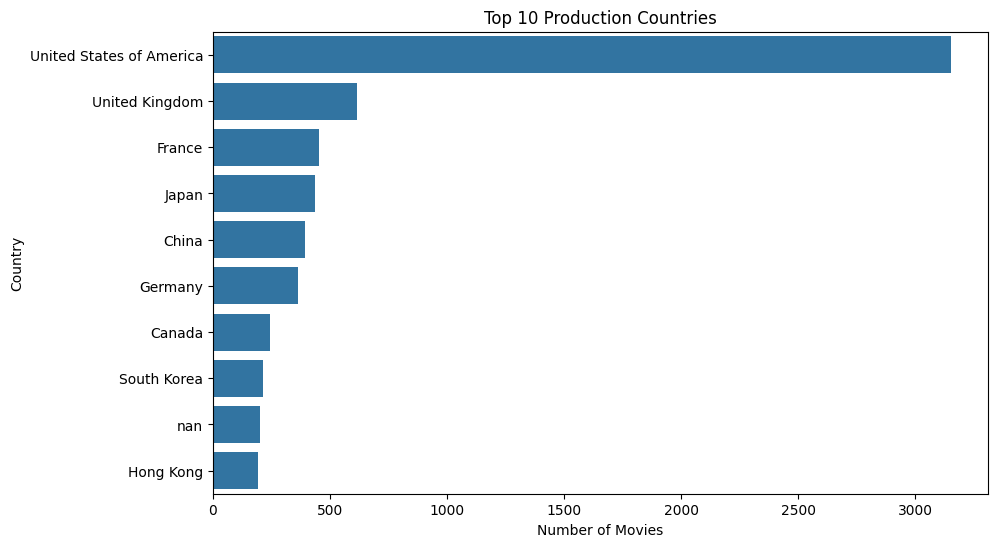

In [ ]:
country_df = df.assign(
    Production_Countries=df["Production_Countries"]
    .astype(str)
    .str.split(", ")
).explode("Production_Countries")

country_counts = (
    country_df["Production_Countries"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title("Top 10 Production Countries")
plt.xlabel("Number of Movies")
plt.ylabel("Country")
plt.show()


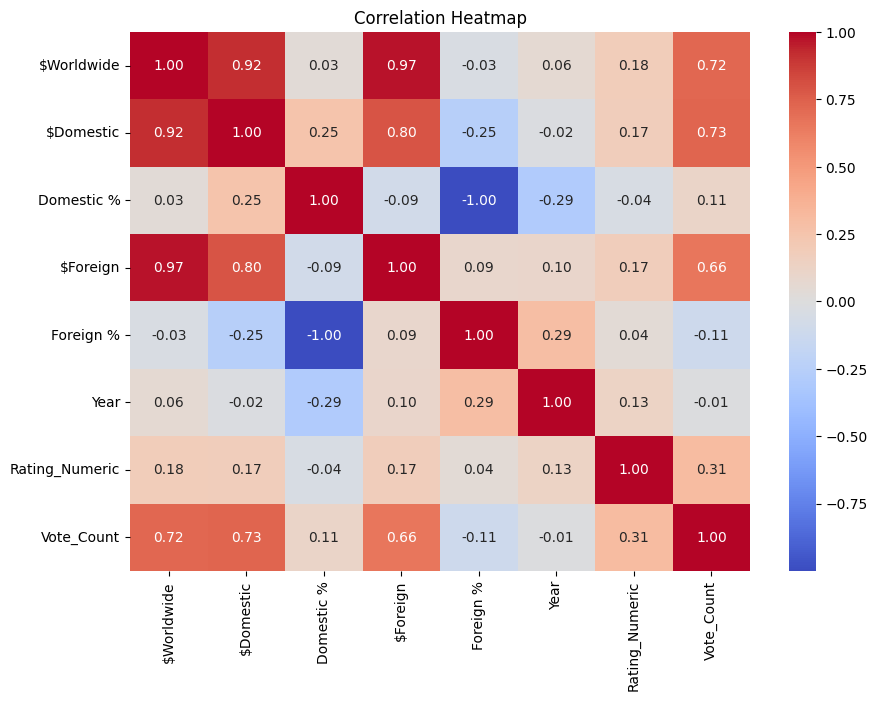

In [ ]:
numeric_columns = [
    "$Worldwide",
    "$Domestic",
    "Domestic %",
    "$Foreign",
    "Foreign %",
    "Year",
    "Rating_Numeric",
    "Vote_Count"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
top_votes = df.sort_values(
    by="Vote_Count",
    ascending=False
).head(10)

print("\nTop 10 Most Voted Movies:")
print(
    top_votes[
        ["Release Group", "Vote_Count", "Rating_Numeric", "$Worldwide"]
    ]
)


Top 10 Most Voted Movies:
                              Release Group  Vote_Count  Rating_Numeric  \
2003                              Inception     36753.0           8.370   
2809                           Interstellar     35934.0           8.400   
1600                        The Dark Knight     33108.0           8.500   
1800                                 Avatar     31654.0           7.583   
3208                               Deadpool     31141.0           7.624   
2400                           The Avengers     30942.0           7.724   
3600                 Avengers: Infinity War     29914.0           8.242   
2802                Guardians of the Galaxy     28085.0           7.906   
200   Harry Potter and the Sorcerer's Stone     27607.0           7.907   
1607                               Iron Man     26470.0           7.647   

        $Worldwide  
2003  8.282587e+08  
2809  6.810704e+08  
1600  1.003845e+09  
1800  2.743578e+09  
3208  7.826122e+08  
2400  1.518813e+09  


In [ ]:
top_rated = df.sort_values(
    by="Rating_Numeric",
    ascending=False
).head(10)

print("\nTop 10 Highest Rated Movies:")
print(
    top_rated[
        ["Release Group", "Rating_Numeric", "Vote_Count", "$Worldwide"]
    ]
)




Top 10 Highest Rated Movies:
                                          Release Group  Rating_Numeric  \
4988         Attack on Titan the Movie: The Last Attack           9.700   
4945                            The Enchanted Tinderbox           9.000   
4120                       Break the Silence: The Movie           9.000   
3359                                            Pandora           9.000   
4950                                     I'm Still Here           8.917   
4477  BTS Permission to Dance on Stage - Seoul: Live...           8.900   
4978  Uma Musume: Pretty Derby - Beginning of a New Era           8.700   
4513                                          Godfather           8.690   
4688                     Renaissance: A Film by Beyoncé           8.600   
4795                            Pretty Cure All Stars F           8.600   

      Vote_Count  $Worldwide  
4988         3.0   7796800.0  
4945         2.0  11676459.0  
4120       182.0   8954345.0  
3359         1.0  30

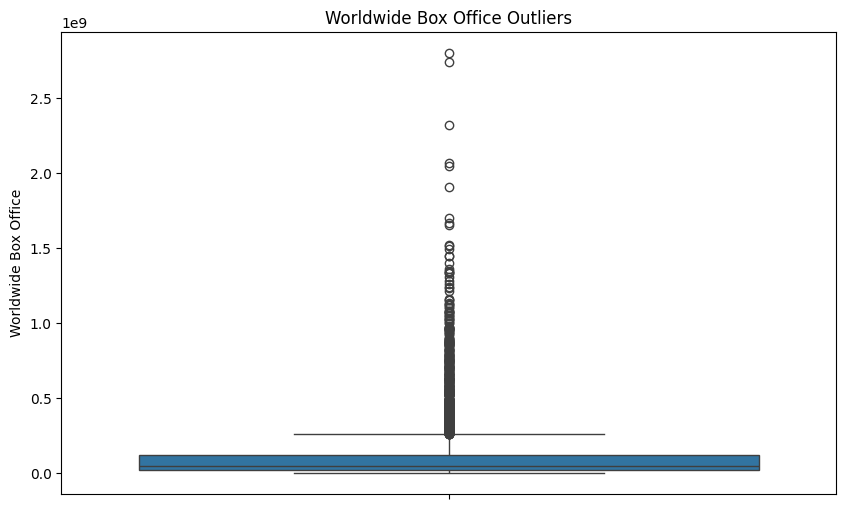

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    y=df["$Worldwide"]
)

plt.title("Worldwide Box Office Outliers")
plt.ylabel("Worldwide Box Office")
plt.show()